### Set-Up

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Visual Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
%matplotlib inline

### Loading and Exploring Raw Data

In [3]:
# Load CSV File
df = pd.read_csv("IAP_Answers.csv")

print("====DATASET OVERVIEW===")
print(f"Total responses: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("="*23+"\n")
print("===COLUMNS OVERVIEW===")
print("Column names:")
for col in df.columns:
    print(f"   - {col}")
print("="*100)

====DATASET OVERVIEW===
Total responses: 21
Columns: 12

===COLUMNS OVERVIEW===
Column names:
   - Timestamp
   - Username
   - Data Privacy Act

Republic Act No. 10173, otherwise known as the Data Privacy Act is a law that seeks to protect all forms of information, be it private, personal, or sensitive. It is meant to cover both natural and juridical persons involved in the processing of personal information.
   - Name
   - Age
   - Sex/Gender
   - 1. When do you mostly use the internet? (Choose one)
   - 2. How many hours per day do you use the internet?
   - 3. What do you mostly use the internet for? (Check all that apply)
   - 4. Which platform do you use the most?  (Check all that apply)
   - 5. Where do you usually access the internet? (Check all that apply)
   - 6. What device do you mostly use to access the internet? (Check all that apply)


In [4]:
display(df.head(21))

,Timestamp,Username,"Data Privacy Act\n\nRepublic Act No. 10173, otherwise known as the Data Privacy Act is a law that seeks to protect all forms of information, be it private, personal, or sensitive. It is meant to cover both natural and juridical persons involved in the processing of personal information.",Name,Age,Sex/Gender,1. When do you mostly use the internet? (Choose one),2. How many hours per day do you use the internet?,3. What do you mostly use the internet for? (Check all that apply),4. Which platform do you use the most? (Check all that apply),5. Where do you usually access the internet? (Check all that apply),6. What device do you mostly use to access the internet? (Check all that apply)
0,2025/12/02 9:25:35 PM GMT+8,esguerraangelinanicole@gmail.com,I wish to continue.,Angelina Nicole O. Esguerra,19,Female,Evening (6 PM – 12 AM),More than 6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Google,At home;At school,Smartphone;Laptop
1,2025/12/02 9:35:03 PM GMT+8,dolflouisefelipe26@gmail.com,I wish to continue.,Dolf,18,Male,Evening (6 PM – 12 AM),More than 6 hours,"Social media (Facebook, TikTok, Instagram);Str...",TikTok;Instagram;YouTube,At home;At school,Smartphone;Laptop
2,2025/12/02 9:39:35 PM GMT+8,joshwesleycasass@gmail.com,I wish to continue.,Josh Wesley Casas,18,Male,Evening (6 PM – 12 AM),5-6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Instagram,At home;Using mobile data,Smartphone;Laptop
3,2025/12/02 9:40:52 PM GMT+8,zl.gellido@gmail.com,I wish to continue.,Zaren Gellido,19,Male,Afternoon (12 PM – 5 PM),More than 6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Instagram;YouTube;Google,At home;At school,Smartphone;Laptop
4,2025/12/02 10:41:36 PM GMT+8,ladangakassandra@gmail.com,I wish to continue.,Kassandra Jade B. Ladanga,18,Female,Evening (6 PM – 12 AM),More than 6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Instagram;Google,At home;Using mobile data,Smartphone;Laptop;Tablet
5,2025/12/03 4:37:13 AM GMT+8,aljhonarquiza9@gmail.com,I wish to continue.,Aljhon Arquiza L.,18,Male,Morning (6 AM – 11 AM),More than 6 hours,"Research / School work;Social media (Facebook,...",Facebook;Instagram;YouTube;Google,At home,Smartphone;Desktop computer
6,2025/12/03 5:08:23 AM GMT+8,jhowenmarcelo37@gmail.com,I wish to continue.,Jhowen Marcelo,18,Male,Afternoon (12 PM – 5 PM),More than 6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;CODM;MLBB;Roblox,At home,Smartphone;Laptop
7,2025/12/03 9:00:38 PM GMT+8,rafaelpalomique02@gmail.com,I wish to continue.,rafael,19,Male,Evening (6 PM – 12 AM),More than 6 hours,"Research / School work;Social media (Facebook,...",TikTok;Instagram;YouTube;Google,At home,Smartphone;Laptop;Desktop computer
8,2025/12/03 10:06:57 PM GMT+8,keibullecer@gmail.com,I wish to continue.,Kathy,18,Female,Morning (6 AM – 11 AM),5-6 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Instagram,At home;Using mobile data,Smartphone;Laptop;Tablet
9,2025/12/03 10:11:26 PM GMT+8,biannchris1@gmail.com,I wish to continue.,Biann Chris R. Evangelista,18,Male,Evening (6 PM – 12 AM),3-4 hours,"Research / School work;Social media (Facebook,...",Facebook;TikTok;Instagram;YouTube;Google;Discord,At home;At school;Using mobile data;Using WiFi...,Smartphone;Laptop


### Data Cleaning

In [5]:
# Creating a clean 'copy'
df_clean = df.copy()

In [6]:
columns_to_remove = [
    'Timestamp',
    'Username',
    'Data Privacy Act\n\nRepublic Act No. 10173, otherwise known as the Data Privacy Act is a law that seeks to protect all forms of information, be it private, personal, or sensitive. It is meant to cover both natural and juridical persons involved in the processing of personal information.',
    'Name',
    'Age',
    'Sex/Gender'
]

df_clean = df_clean.drop(columns=[col for col in columns_to_remove if col in df_clean.columns])

print("Remaining columns for analysis:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"{i}. {col}")

Remaining columns for analysis:
1. 1. When do you mostly use the internet? (Choose one)
2. 2. How many hours per day do you use the internet?
3. 3. What do you mostly use the internet for? (Check all that apply)
4. 4. Which platform do you use the most?  (Check all that apply)
5. 5. Where do you usually access the internet? (Check all that apply)
6. 6. What device do you mostly use to access the internet? (Check all that apply)


In [7]:
column_rename = {
    '1. When do you mostly use the internet? (Choose one)': 'peak_time',
    '2. How many hours per day do you use the internet?': 'daily_hours',
    '3. What do you mostly use the internet for? (Check all that apply)': 'purposes',
    '4. Which platform do you use the most?  (Check all that apply)': 'platforms',  # NEW column
    '5. Where do you usually access the internet? (Check all that apply)': 'access_location',  # NEW column
    '6. What device do you mostly use to access the internet? (Check all that apply)': 'devices'
}
# Renaming for Clarity
df_clean = df_clean.rename(columns=column_rename)
print("Renamed columns")
print("Actual columns after rename:", list(df_clean.columns))

Renamed columns
Actual columns after rename: ['peak_time', 'daily_hours', 'purposes', 'platforms', 'access_location', 'devices']


In [8]:
# Converting it to String and then Splitting it with Semicolon to clean each item
def clean_multiselect(text):
    if pd.isna(text):
        return[]
    items = str(text).split(';')
    return [item.strip() for item in items if item.strip()]    

df_clean['peak_time'] = df_clean['peak_time'].str.strip() # Cleaning single select questionnaire

df_clean['daily_hours'] = df_clean['daily_hours'].str.strip() # Cleaning single select questionnaire

df_clean['purposes_clean'] = df_clean['purposes'].apply(clean_multiselect) # Cleaning Multi-Select

df_clean['devices_clean'] = df_clean['devices'].apply(clean_multiselect) # Cleaning Multi-Select

df_clean['platforms_clean'] = df_clean['platforms'].apply(clean_multiselect)


df_clean = df_clean.drop(columns=['purposes', 'devices', 'platforms']) # To remove original columns

# Finished cleaning atp (CAN RUN ONCE ONLY CAUSE IT WILL COMPLETELY REPLACE NAME OF COLUMNS)

In [9]:
print(f"Dataset shape: {df_clean.shape}")

Dataset shape: (21, 6)


In [10]:
missing = df_clean[['peak_time', 'daily_hours']].isnull().sum()
print("Missing Values in key Collumn")
print(missing[missing > 0]) # To check for missing values

Missing Values in key Collumn
Series([], dtype: int64)


In [11]:
print("\nUnique peak times:")
print(df_clean['peak_time'].unique())

print("\nUnique daily hours:")
print(df_clean['daily_hours'].unique())


Unique peak times:
['Evening (6 PM – 12 AM)' 'Afternoon (12 PM – 5 PM)'
 'Morning (6 AM – 11 AM)' 'Late night (12 AM – 3 AM)']

Unique daily hours:
['More than 6 hours' '5-6 hours' '3-4 hours']


In [12]:
peak_counts = df_clean['peak_time'].value_counts().sort_index()
print("Distribution:")
for time, count in peak_counts.items():
    percentage = (count/len(df_clean)) * 100
    print(f"{time}: {count} students({percentage:.1f}%)")

Distribution:
Afternoon (12 PM – 5 PM): 4 students(19.0%)
Evening (6 PM – 12 AM): 12 students(57.1%)
Late night (12 AM – 3 AM): 1 students(4.8%)
Morning (6 AM – 11 AM): 4 students(19.0%)


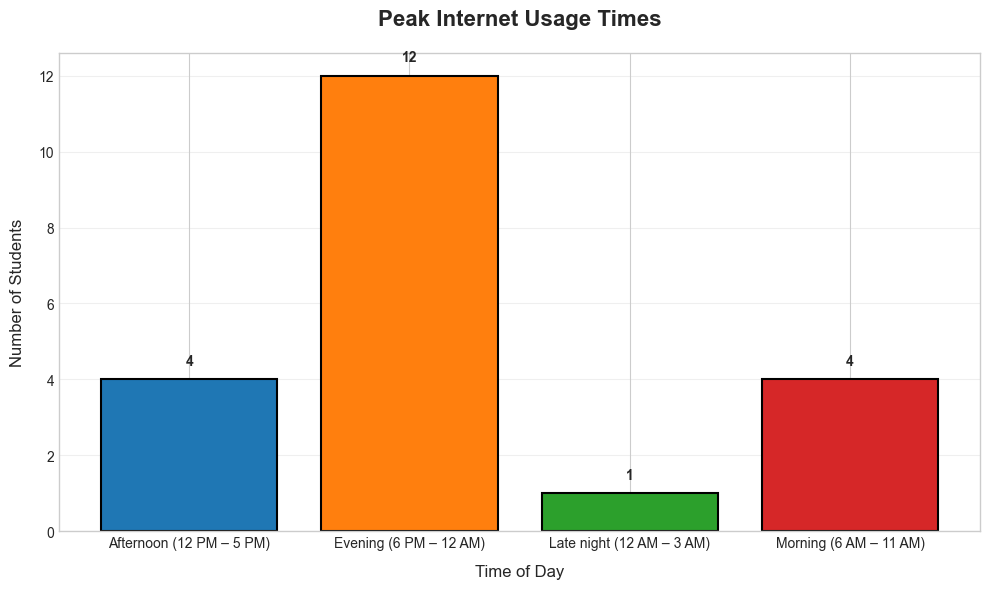

In [13]:
# Data Labeling
# 
plt.figure(figsize=(10,6))
bars = plt.bar(peak_counts.index, peak_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{int(height)}', ha='center', va='bottom', fontweight='bold')
 
plt.title('Peak Internet Usage Times', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time of Day', fontsize=12, labelpad=10)
plt.ylabel('Number of Students', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('peak_time_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
all_purposes=[]
for purposes_list in df_clean['purposes_clean']:
    all_purposes.extend(purposes_list)

purpose_counts = Counter(all_purposes)
purpose_df = pd.DataFrame(purpose_counts.items(), columns=['Purpose', 'Count'])
purpose_df = purpose_df.sort_values('Count', ascending=True)
# Horizontal Sorting
print(f"Total purpose mentions: {len(all_purposes)}")
print(f"Unique purposes: {len(purpose_df)}")
print("Top purposes: ")
for _, row in purpose_df.tail(6).iterrows():
    percentage=(row['Count']/ len(df_clean)) * 100
    print(f"{row['Purpose']}: {row['Count']} mentions ({percentage:.0f}% of students)")

Total purpose mentions: 105
Unique purposes: 7
Top purposes: 
Online shopping: 9 mentions (43% of students)
Online gaming: 16 mentions (76% of students)
Streaming videos (YouTube, Netflix, etc.): 16 mentions (76% of students)
Research / School work: 17 mentions (81% of students)
Social media (Facebook, TikTok, Instagram): 18 mentions (86% of students)
Communication (Messenger, Discord, etc.): 20 mentions (95% of students)


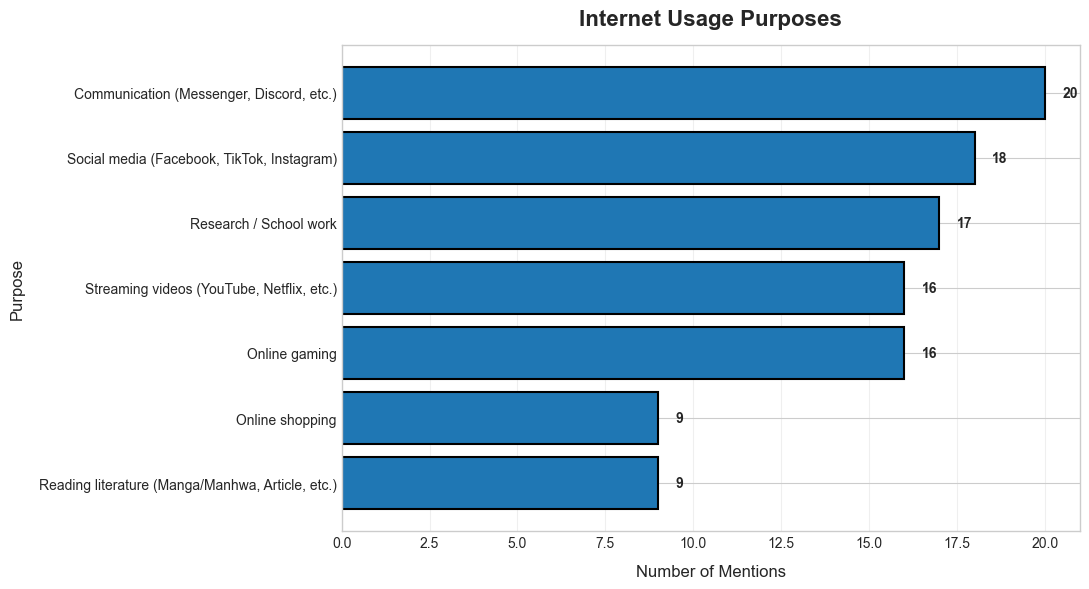

In [15]:
# Horizantoal Chart
plt.figure(figsize=(11, 6))
bars = plt.barh(purpose_df['Purpose'], purpose_df['Count'], 
                color='#1f77b4', edgecolor='black', linewidth=1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.title('Internet Usage Purposes', fontsize=16, fontweight='bold', pad=14)
plt.xlabel('Number of Mentions', fontsize=12, labelpad=10)
plt.ylabel('Purpose', fontsize=12, labelpad=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('purposes_chart.png', dpi=300, bbox_inches='tight')
plt.show()


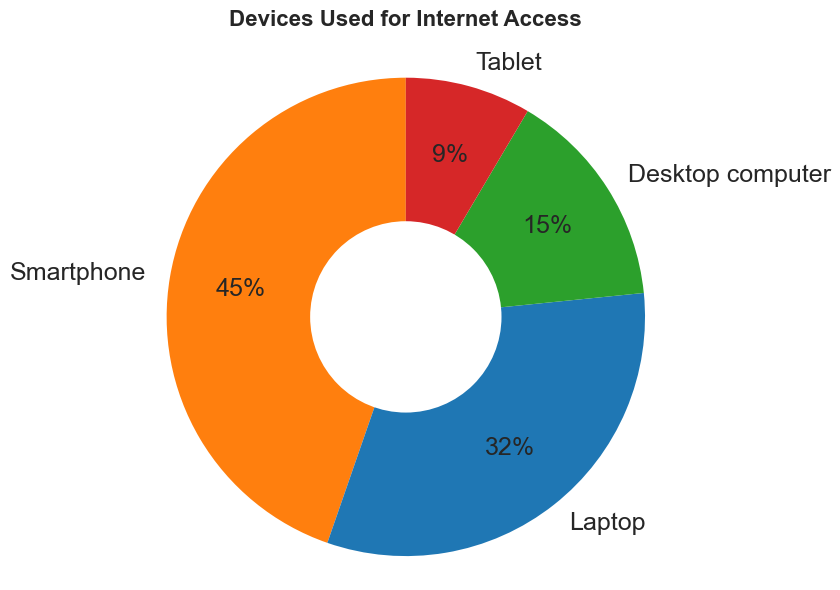

In [16]:
all_devices = []
for devices_list in df_clean['devices_clean']:
    all_devices.extend(devices_list)

device_counts = Counter(all_devices)
device_df = pd.DataFrame(device_counts.items(), columns=['Device','Count'])
device_df = device_df.sort_values('Count', ascending=False)
plt.figure(figsize=(8, 6))
colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728'][:len(device_df)]

wedges, texts, autotexts = plt.pie(device_df['Count'], labels=device_df['Device'], colors=colors, autopct='%1.0f%%', startangle=90, pctdistance=0.70, textprops={'fontsize': 18})

centre_circle = plt.Circle((0,0), 0.4, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Devices Used for Internet Access', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()

plt.savefig('device_chart.png', dpi=300, bbox_inches='tight')
plt.show()

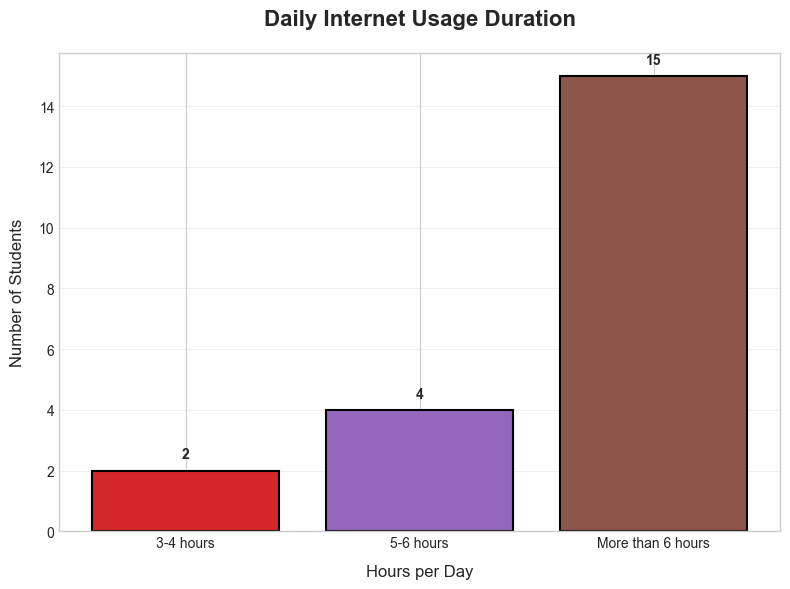

In [17]:
hour_order = ['3-4 hours', '5-6 hours', 'More than 6 hours'] # Ordering categories
hour_counts = df_clean['daily_hours'].value_counts().reindex(hour_order)

plt.figure(figsize=(8,6))
bars = plt.bar(hour_counts.index, hour_counts.values, 
               color=['#d62728', '#9467bd', '#8c564b'],
               edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title('Daily Internet Usage Duration', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hours per Day', fontsize=12, labelpad=10)
plt.ylabel('Number of Students', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('daily_hours_chart.png', dpi=300, bbox_inches='tight')
plt.show()

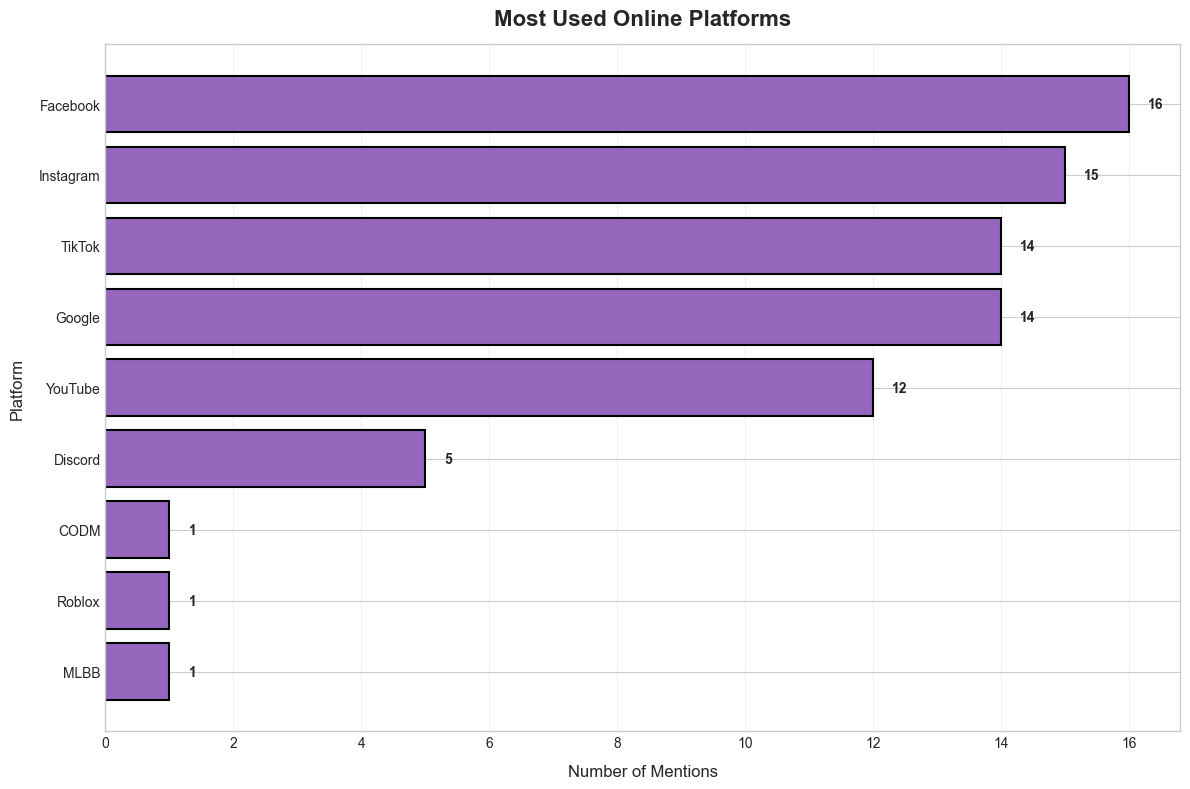

In [18]:
all_platforms = []
for platforms_list in df_clean['platforms_clean']:
    all_platforms.extend(platforms_list)

platform_counts = Counter(all_platforms)
platform_df = pd.DataFrame(platform_counts.items(), columns=['Platform', 'Count'])
platform_df = platform_df.sort_values('Count', ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(platform_df['Platform'], platform_df['Count'], 
                color='#9467bd', edgecolor='black', linewidth=1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.title('Most Used Online Platforms', fontsize=16, fontweight='bold', pad=14)
plt.xlabel('Number of Mentions', fontsize=12, labelpad=10)
plt.ylabel('Platform', fontsize=12, labelpad=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('platforms_chart.png', dpi=300, bbox_inches='tight')
plt.show()
